In [2]:
import pandas as pd
import numpy as np

base_path = '.'



In [3]:
a_date = np.datetime64('2011-07-25 03:30:00')

In [4]:
def get_date_attributes(_date):
    _year = pd.to_datetime(_date).year
    _month = "{0:0>2}".format( pd.to_datetime(_date).month )
    _day = "{0:0>2}".format( pd.to_datetime(_date).day )
    _hour = "{0:0>2}".format( pd.to_datetime(_date).hour )
    _minute = "{0:0>2}".format( pd.to_datetime(_date).minute )
    return _year, _month, _day, _hour, _minute


In [6]:
def locate_xray_series(start_date, end_date, _goes = 'goes15'):
    s_year, s_month, s_day, s_hour, s_minute = get_date_attributes(start_date)
    e_year, e_month, e_day, e_hour, e_minute = get_date_attributes(end_date)
    print(get_date_attributes(start_date))
    
    start_day = np.datetime64( str(start_date).partition('T')[0] )
    end_day = np.datetime64( str(end_date).partition('T')[0] )
    
    _xrs = pd.DataFrame(columns=['A_QUAL_FLAG', 'A_COUNT', 'A_FLUX', 
                                 'B_QUAL_FLAG', 'B_COUNT', 'B_FLUX'])
    temp = start_day
    while temp != end_day + np.timedelta64(24, 'h'):
        daily_series = get_xray_series(temp, _goes)
        if temp == start_day:
            if temp == end_day:
                return daily_series.loc[start_date:end_date]
            else:
                _xrs = pd.concat( [_xrs, daily_series.loc[start_date:]] )
        elif temp == end_day:
            _xrs = pd.concat( [_xrs, daily_series.loc[:end_date] ] )
        else:
            _xrs = pd.concat([_xrs, daily_series])
        
        temp = temp + np.timedelta64(24, 'h')
    return _xrs

def get_xray_series(_date, valid_goes='goes15'):
    s_year, s_month, s_day, s_hour, s_minute = get_date_attributes(_date)

    folder_path = base_path + '/' + str(s_year) + '/' + str(s_month) + '/' + valid_goes + '/csv/'
    file_name = 'g{0}_xrs_2s_{1}{2}{3}_{1}{2}{3}.csv'.format(valid_goes.strip('goes'), s_year, s_month, s_day)
    file_path = folder_path + file_name
    
    cnt = 1
    with open(file_path) as fp:  
        line = fp.readline()
        while line:
            line = fp.readline()
            if line.strip() == 'data:':
                break
            cnt += 1
    xrs_df = pd.read_csv(folder_path + file_name, index_col='time_tag', parse_dates=True, skiprows = cnt+1) # 
    return xrs_df
    


In [7]:
a_date = np.datetime64('2011-09-04 00:00:00')
my_xrs = locate_xray_series(a_date, a_date+np.timedelta64(24,'h'))

(2011, '09', '04', '00', '00')


In [8]:
max_bflux = np.max(my_xrs['B_FLUX']) 

In [9]:


def get_cw_max_flux(start_date, end_date):
    from sunpy.instr.goes import flux_to_flareclass
    import astropy.units as u
    
    my_xrs = locate_xray_series(start_date, end_date)
    max_bflux = np.max(my_xrs['B_FLUX']) 
    return flux_to_flareclass(max_bflux * u.watt/u.m**2)


In [10]:
def fix_noaa_ar_numbers(df):
    """ Replace the noaa ar numbers that are zero with the nan's
        :param df: flare data frame
        :return: noaa numbers fixed flare data frame
    """
    df.loc[df['noaa_active_region'] == 0, 'noaa_active_region'] = np.nan
    df.loc[df['noaa_active_region'] <= 10000, 'noaa_active_region'] = df.loc[df[
                                                                                 'noaa_active_region'] <= 10000, 'noaa_active_region'] + 10000
    return df

def get_flare_dataframe(file_path):
    """Reads the flare dataframe given in flare file path, downloaded using our script"""
    df = pd.read_csv(file_path, delimiter=',', parse_dates=['start_time', 'end_time', 'peak_time'])
    df = df.set_index('flare_id')

    return fix_noaa_ar_numbers(df)
flare_file_path = '/home/baydin2/workspace/flarepredictiondata/flare_reading/datain/final/goes_aia_validated.csv'
fdf = get_flare_dataframe(flare_file_path)
sep4 = fdf[fdf['event_date'] == '2011-09-04']

In [11]:
sep4[['peak_time', 'goes_class']]

,peak_time,goes_class
flare_id,,
2369,2011-09-04 01:07:00,C8.3
2370,2011-09-04 04:53:00,C9.0
2371,2011-09-04 06:18:00,C4.0
2372,2011-09-04 11:45:00,M3.2
2373,2011-09-04 15:34:00,C5.8


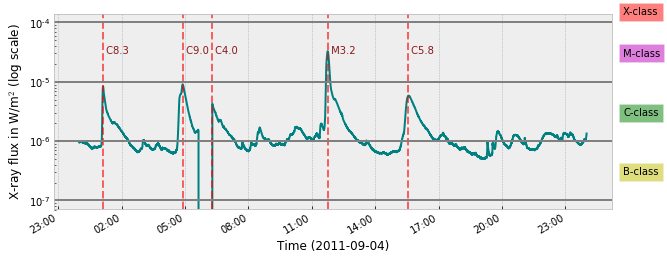

In [12]:
%matplotlib inline

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('bmh')

fig, ax = plt.subplots(figsize=(10,4))

    
ax = my_xrs['B_FLUX'].plot(linewidth=2, color='teal', ax = ax)
plt.yscale('log')
plt.ylabel('X-ray flux in W/m$^2$ (log scale)')
plt.xlabel('Time (2011-09-04)')


myFmt = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(myFmt)

xposition = sep4['peak_time'].values
xtext = sep4['goes_class'].values

i = 0
for xc in xposition:
    ax.axvline(x=xc, color='r', linestyle='dashed', alpha = 0.6)
    style = dict(size=10, color='maroon', alpha = 0.9)
    ax.text(xc, 0.00003, " " + xtext[i], ha='left', **style)
    i = i+1

    
ax.axhline(1.0e-4, color="gray")
ax.text(1.02, 1.5e-4, "X-class", va='center', ha="left", bbox=dict(facecolor="r",alpha=0.5),
        transform=ax.get_yaxis_transform())
ax.axhline(1.0e-5, color="gray")
ax.text(1.02, 3.0e-5, "M-class", va='center', ha="left", bbox=dict(facecolor="m",alpha=0.5),
        transform=ax.get_yaxis_transform())
ax.axhline(1.0e-6, color="gray")
ax.text(1.02, 3.0e-6, "C-class", va='center', ha="left", bbox=dict(facecolor="g",alpha=0.5),
        transform=ax.get_yaxis_transform())
ax.axhline(1.0e-7, color="gray")
ax.text(1.02, 3.0e-7, "B-class", va='center', ha="left", bbox=dict(facecolor="y",alpha=0.5),
        transform=ax.get_yaxis_transform())

fig.savefig('xray_example.pdf', bbox_inches='tight', transparent=True, pad_inches=0)

In [13]:
# print(plt.style.available)

In [22]:
# my_xrs.iloc[0]

my_xrs.iloc[20000:20010]

,A_QUAL_FLAG,A_COUNT,A_FLUX,B_QUAL_FLAG,B_COUNT,B_FLUX
2011-09-04 11:23:36.180,0,19011.0,1.632000e-07,0,22523.0,0.000002
2011-09-04 11:23:38.230,0,19035.0,1.665400e-07,0,22571.0,0.000002
2011-09-04 11:23:40.277,0,19067.0,1.710000e-07,0,22603.0,0.000002
2011-09-04 11:23:42.327,0,19083.0,1.732300e-07,0,22659.0,0.000002
2011-09-04 11:23:44.373,0,19099.0,1.754600e-07,0,22699.0,0.000002
2011-09-04 11:23:46.420,0,19139.0,1.810300e-07,0,22731.0,0.000002
2011-09-04 11:23:48.470,0,19155.0,1.832600e-07,0,22755.0,0.000002
2011-09-04 11:23:50.517,0,19163.0,1.843700e-07,0,22795.0,0.000002
2011-09-04 11:23:52.567,0,19179.0,1.866000e-07,0,22827.0,0.000002
2011-09-04 11:23:54.613,0,19187.0,1.877200e-07,0,22835.0,0.000002
